## 기상청 공공데이터 

>  **데이터 출처**: 기상청_지상(종관, ASOS) 일자료 조회서비스       
> https://www.data.go.kr/data/15059093/openapi.do

## 라이브러리 불러오기

| 라이브러리 | 용도 |
|------------|------|
| `requests` | 인터넷(Open API)에서 데이터 받아오기 |

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
import requests

In [35]:
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

## Open API 활용하여 데이터 수집


```
우리 ──── 요청(Request) ────▶ 서버(공공데이터포털)
     ◀─── 응답(Response) ────
```

- **API** (Application Programming Interface) : 프로그램끼리 대화하는 창구
- **Open API** : 누구나 키(API Key)를 발급받아 사용할 수 있는 공개 API
- 우리는 **URL 주소**로 요청을 보내고, **JSON 형식**으로 데이터를 받습니다.


### URL 구성하기

요청 URL은 **endpoint 주소 + 파라미터(요청 조건)** 로 구성됩니다.
> 파라미터는 `?`로 시작하고, 각 파라미터는 `&`로 구분합니다.

In [36]:
url= 'http://apis.data.go.kr/1360000/AsosDalyInfoService/getWthrDataList'

In [37]:
mykey = 'b70d84df27e9d6c755d17a37c81df05f9da9c55dd4b225851c323cc8438bb232'  # 여러분 것으로 교체하세요

In [61]:
parameter={
            'serviceKey':mykey,   
            'numOfRows':'400',
            'pageNo':'1', 
            'dataCd':'ASOS',                                           # 자료 분류 코드(ASOS)
            'dateCd':'DAY',                                            # 날짜 분류 코드(DAY)
            'startDt':'20250101',
            'endDt':'20251231',
            'stnIds':'108',                                            # 108 서울지역임, 다른 지역은 참고문서의 코드값 참고
            'dataType':'JSON' 
           }

In [39]:
requests.get(url,params=parameter )

<Response [200]>

### 데이터 요청하기 — `requests.get()`

| 코드 | 의미 |
|------|------|
| `requests.get(url)` | URL로 데이터 요청 → **Response 객체** 반환 |
| `requests.get(url).text` | 응답 내용을 **문자열(str)** 로 반환 |
| `requests.get(url).json()` | 응답 JSON 문자열을 **파이썬 딕셔너리** 로 변환 |

> **JSON** (JavaScript Object Notation) : 인터넷에서 데이터를 주고받는 표준 형식     
> 파이썬의 **딕셔너리 `{}`** 와 구조가 같아요!     
> `requests.get(url).json()` 으로 **바로 딕셔너리**로 변환할 수 있습니다   

In [62]:
data = requests.get(url,params=parameter ).json()
data

{'response': {'header': {'resultCode': '00', 'resultMsg': 'NORMAL_SERVICE'},
  'body': {'dataType': 'JSON',
   'items': {'item': [{'stnId': '108',
      'stnNm': '서울',
      'tm': '2025-01-01',
      'avgTa': '2.6',
      'minTa': '-2.5',
      'minTaHrmt': '0441',
      'maxTa': '8.9',
      'maxTaHrmt': '1540',
      'mi10MaxRn': '',
      'mi10MaxRnHrmt': '',
      'hr1MaxRn': '',
      'hr1MaxRnHrmt': '',
      'sumRnDur': '',
      'sumRn': '',
      'maxInsWs': '9.7',
      'maxInsWsWd': '290',
      'maxInsWsHrmt': '1417',
      'maxWs': '5.1',
      'maxWsWd': '250',
      'maxWsHrmt': '1519',
      'avgWs': '2.2',
      'hr24SumRws': '1861',
      'maxWd': '250',
      'avgTd': '-3.6',
      'minRhm': '49',
      'minRhmHrmt': '1543',
      'avgRhm': '64.3',
      'avgPv': '4.8',
      'avgPa': '1011.0',
      'maxPs': '1023.1',
      'maxPsHrmt': '2359',
      'minPs': '1020.0',
      'minPsHrmt': '1446',
      'avgPs': '1021.8',
      'ssDur': '9.6',
      'sumSsHr': '5.6',


## 딕셔너리 구조 탐색하기

받아온 데이터 구조를 한 단계씩 파고들어 봅니다.

```
data
 └─ 'response'
      └─ 'body'
           └─ 'items'  
              └─ 'item'← 우리가 원하는 실제 데이터 목록!
                └─ [ {row1}, {row2}, ... ]   ← 딕셔너리들의 리스트
```

In [ ]:
#data['response']['body']['items']['item']

In [42]:
data['response']['body']['items']['item']

[{'stnId': '108',
  'stnNm': '서울',
  'tm': '2020-01-01',
  'avgTa': '-2.2',
  'minTa': '-6.5',
  'minTaHrmt': '0001',
  'maxTa': '0.3',
  'maxTaHrmt': '1457',
  'mi10MaxRn': '',
  'mi10MaxRnHrmt': '',
  'hr1MaxRn': '',
  'hr1MaxRnHrmt': '',
  'sumRnDur': '9.83',
  'sumRn': '0.1',
  'maxInsWs': '4.8',
  'maxInsWsWd': '50',
  'maxInsWsHrmt': '0906',
  'maxWs': '2.6',
  'maxWsWd': '50',
  'maxWsHrmt': '0904',
  'avgWs': '0.6',
  'hr24SumRws': '509',
  'maxWd': '50',
  'avgTd': '-8.1',
  'minRhm': '37',
  'minRhmHrmt': '0002',
  'avgRhm': '64.4',
  'avgPv': '3.4',
  'avgPa': '1021.1',
  'maxPs': '1034.0',
  'maxPsHrmt': '0952',
  'minPs': '1031.2',
  'minPsHrmt': '1418',
  'avgPs': '1032.1',
  'ssDur': '9.6',
  'sumSsHr': '0.8',
  'hr1MaxIcsrHrmt': '1100',
  'hr1MaxIcsr': '1.0',
  'sumGsr': '4.53',
  'ddMefs': '0.0',
  'ddMefsHrmt': '',
  'ddMes': '0.0',
  'ddMesHrmt': '',
  'sumDpthFhsc': '0.0',
  'avgTca': '8.9',
  'avgLmac': '8.9',
  'avgTs': '-0.9',
  'minTg': '-6.6',
  'avgCm5Te': '-0

## 리스트 → DataFrame 변환 & csv 저장

딕셔너리들의 리스트 → `pd.DataFrame()` 으로 **DataFrame**  만들 수 있어요!

```python
pd.DataFrame( [딕셔너리, 딕셔너리, ...] )

In [63]:
df = pd.DataFrame(data['response']['body']['items']['item'])
df

,stnId,stnNm,tm,avgTa,minTa,minTaHrmt,maxTa,maxTaHrmt,mi10MaxRn,mi10MaxRnHrmt,...,avgM05Te,avgM10Te,avgM15Te,avgM30Te,avgM50Te,sumLrgEv,sumSmlEv,n99Rn,iscs,sumFogDur
0,108,서울,2025-01-01,2.6,-2.5,0441,8.9,1540,,,...,3.4,6.9,10.0,16.7,18.1,1.3,1.9,,,
1,108,서울,2025-01-02,0.5,-2.9,0804,6.0,1507,,,...,3.4,6.8,9.9,16.6,18.0,1.9,2.6,,,
2,108,서울,2025-01-03,-1.1,-5.1,0522,3.2,1551,,,...,3.3,6.7,9.8,16.5,18.0,1.3,1.9,0.0,{눈}2052-{눈}{강도0}2100-2122.,
3,108,서울,2025-01-04,-0.1,-5.4,0752,5.7,1503,,,...,3.2,6.7,9.7,16.4,18.0,1.6,2.3,4.4,,
4,108,서울,2025-01-05,1.2,-0.7,0109,2.5,2353,,,...,3.2,6.6,9.6,16.3,17.9,0.3,0.4,5.3,{눈}0255-{눈}{강도0}0300-0335. {눈}0525-{눈}{강도0}060...,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,108,서울,2025-12-27,-2.6,-8.3,0022,0.5,1550,,,...,4.4,8.0,11.6,17.3,19.3,0.8,1.2,,{눈}0705-0725.,
361,108,서울,2025-12-28,3.2,0.0,0001,6.1,1518,,,...,4.1,7.8,11.4,17.2,19.2,0.7,1.0,0.9,{연무}0455-{연무}{강도0}0600-{연무}{강도0}0900-{연무}{강도0}...,
362,108,서울,2025-12-29,4.9,-0.1,2345,9.1,1446,,,...,4.0,7.6,11.2,17.1,19.2,1.2,1.7,,{박무}0020-{박무}{강도0}0300-{박무}{강도0}0600-{박무}{강도1}...,
363,108,서울,2025-12-30,-0.5,-3.7,0802,3.8,1446,,,...,4.1,7.4,11.1,17.0,19.2,1.9,2.7,,,


## csv 파일로 저장하기

- `to_csv('파일명.csv', index=False)` — DataFrame을 CSV 파일로 저장
- `index=False` — 인덱스 번호(0, 1, 2...)를 파일의 새로운 Index 열로 만들지 않음
- 저장 후 `read_csv()`로 다시 불러오면 **파일 저장 확인** 가능!

In [64]:
df.to_csv('weather_2025.csv',  index=False)

## 여러 연도의 데이터를 수집하여 하나의 파일로 결합

### 2020, 2021,2022,2023,2024, 2025년도 기상청 데이터파일 만들기

In [ ]:
pd.concat?

In [65]:
df_2020 = pd.read_csv('weather_2020.csv')
df_2021 = pd.read_csv('weather_2021.csv')
df_2022 = pd.read_csv('weather_2022.csv')
df_2023 = pd.read_csv('weather_2023.csv')
df_2024 = pd.read_csv('weather_2024.csv')
df_2025 = pd.read_csv('weather_2025.csv')

In [66]:
df = pd.concat([df_2020,df_2021, df_2022, df_2023, df_2024, df_2025], ignore_index=True )

In [67]:
df

,stnId,stnNm,tm,avgTa,minTa,minTaHrmt,maxTa,maxTaHrmt,mi10MaxRn,mi10MaxRnHrmt,...,avgM05Te,avgM10Te,avgM15Te,avgM30Te,avgM50Te,sumLrgEv,sumSmlEv,n99Rn,iscs,sumFogDur
0,108,서울,2020-01-01,-2.2,-6.5,1.0,0.3,1457,NaN,NaN,...,4.1,7.2,9.8,15.3,17.0,0.4,0.6,0.1,-{눈}-0230. {눈}0335-0440. {눈}0520-{눈}{강도0}0600-...,NaN
1,108,서울,2020-01-02,1.0,-0.7,1.0,3.8,1500,NaN,NaN,...,3.7,7.0,9.7,15.2,17.0,0.7,1.0,NaN,-{연무}-{연무}{강도0}0300-{연무}{강도0}0600-{연무}{강도0}090...,NaN
2,108,서울,2020-01-03,-0.1,-3.4,807.0,4.6,1547,NaN,NaN,...,3.6,6.8,9.6,15.1,16.9,1.4,1.9,NaN,{박무}0110-{박무}{강도1}0300-{박무}{강도1}0600-{박무}{강도0}...,NaN
3,108,서울,2020-01-04,1.2,-2.8,512.0,6.1,1450,NaN,NaN,...,3.6,6.7,9.5,15.1,16.9,1.5,2.1,NaN,-{연무}-{연무}{강도0}0300-{연무}{강도0}0600-{연무}{강도0}090...,NaN
4,108,서울,2020-01-05,1.3,-3.2,821.0,6.6,1453,NaN,NaN,...,3.5,6.5,9.3,15.0,16.9,1.5,2.1,NaN,{연무}0810-{연무}{강도0}0900-1140. {연무}1250-1320.,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2187,108,서울,2025-12-27,-2.6,-8.3,22.0,0.5,1550,NaN,NaN,...,4.4,8.0,11.6,17.3,19.3,0.8,1.2,NaN,{눈}0705-0725.,NaN
2188,108,서울,2025-12-28,3.2,0.0,1.0,6.1,1518,NaN,NaN,...,4.1,7.8,11.4,17.2,19.2,0.7,1.0,0.9,{연무}0455-{연무}{강도0}0600-{연무}{강도0}0900-{연무}{강도0}...,NaN
2189,108,서울,2025-12-29,4.9,-0.1,2345.0,9.1,1446,NaN,NaN,...,4.0,7.6,11.2,17.1,19.2,1.2,1.7,NaN,{박무}0020-{박무}{강도0}0300-{박무}{강도0}0600-{박무}{강도1}...,NaN
2190,108,서울,2025-12-30,-0.5,-3.7,802.0,3.8,1446,NaN,NaN,...,4.1,7.4,11.1,17.0,19.2,1.9,2.7,NaN,NaN,NaN


In [68]:
df.to_csv('weather_2020_2025.csv', index=False)

In [69]:
df = pd.read_csv('weather_2020_2025.csv')
df

,stnId,stnNm,tm,avgTa,minTa,minTaHrmt,maxTa,maxTaHrmt,mi10MaxRn,mi10MaxRnHrmt,...,avgM05Te,avgM10Te,avgM15Te,avgM30Te,avgM50Te,sumLrgEv,sumSmlEv,n99Rn,iscs,sumFogDur
0,108,서울,2020-01-01,-2.2,-6.5,1.0,0.3,1457,NaN,NaN,...,4.1,7.2,9.8,15.3,17.0,0.4,0.6,0.1,-{눈}-0230. {눈}0335-0440. {눈}0520-{눈}{강도0}0600-...,NaN
1,108,서울,2020-01-02,1.0,-0.7,1.0,3.8,1500,NaN,NaN,...,3.7,7.0,9.7,15.2,17.0,0.7,1.0,NaN,-{연무}-{연무}{강도0}0300-{연무}{강도0}0600-{연무}{강도0}090...,NaN
2,108,서울,2020-01-03,-0.1,-3.4,807.0,4.6,1547,NaN,NaN,...,3.6,6.8,9.6,15.1,16.9,1.4,1.9,NaN,{박무}0110-{박무}{강도1}0300-{박무}{강도1}0600-{박무}{강도0}...,NaN
3,108,서울,2020-01-04,1.2,-2.8,512.0,6.1,1450,NaN,NaN,...,3.6,6.7,9.5,15.1,16.9,1.5,2.1,NaN,-{연무}-{연무}{강도0}0300-{연무}{강도0}0600-{연무}{강도0}090...,NaN
4,108,서울,2020-01-05,1.3,-3.2,821.0,6.6,1453,NaN,NaN,...,3.5,6.5,9.3,15.0,16.9,1.5,2.1,NaN,{연무}0810-{연무}{강도0}0900-1140. {연무}1250-1320.,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2187,108,서울,2025-12-27,-2.6,-8.3,22.0,0.5,1550,NaN,NaN,...,4.4,8.0,11.6,17.3,19.3,0.8,1.2,NaN,{눈}0705-0725.,NaN
2188,108,서울,2025-12-28,3.2,0.0,1.0,6.1,1518,NaN,NaN,...,4.1,7.8,11.4,17.2,19.2,0.7,1.0,0.9,{연무}0455-{연무}{강도0}0600-{연무}{강도0}0900-{연무}{강도0}...,NaN
2189,108,서울,2025-12-29,4.9,-0.1,2345.0,9.1,1446,NaN,NaN,...,4.0,7.6,11.2,17.1,19.2,1.2,1.7,NaN,{박무}0020-{박무}{강도0}0300-{박무}{강도0}0600-{박무}{강도1}...,NaN
2190,108,서울,2025-12-30,-0.5,-3.7,802.0,3.8,1446,NaN,NaN,...,4.1,7.4,11.1,17.0,19.2,1.9,2.7,NaN,NaN,NaN


참고: 다음과 같이 반복문으로 해도 됩니다!
```
df_list = []

for year in range(2020, 2026):
    df = pd.read_csv(f'weather_{year}.csv')
    df_list.append(df)

df_all = pd.concat(df_list, ignore_index=True)
```

## 데이터 로드 및 EDA

- 기상청 종관기상관측(ASOS) 서울(stnId=108) 일별 관측값      
- 62개 컬럼 중 사용할 핵심 컬럼

| 컬럼 | 의미 | 단위 |
|------|------|------|
| tm | 날짜 | YYYY-MM-DD |
| avgTa | **평균기온** | ℃ |
| minTa | 최저기온 | ℃ |
| maxTa | 최고기온 | ℃ |
| avgRhm | **평균습도** | % |
| avgWs | **평균풍속** | m/s |
| sumRn | **일강수량** | mm |
| avgPa | **평균현지기압** | hPa |
| sumSsHr | 합계일조시간 | hr |
| avgTca | 평균전운량(구름) | 1/10 |
> 전체 컬럼 설명: https://www.data.go.kr/data/15059093/openapi.do


In [70]:
df1 = pd.read_csv('weather_2020_2025.csv')

In [71]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 62 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   stnId           2192 non-null   int64  
 1   stnNm           2192 non-null   object 
 2   tm              2192 non-null   object 
 3   avgTa           2192 non-null   float64
 4   minTa           2191 non-null   float64
 5   minTaHrmt       2191 non-null   float64
 6   maxTa           2192 non-null   float64
 7   maxTaHrmt       2192 non-null   int64  
 8   mi10MaxRn       605 non-null    float64
 9   mi10MaxRnHrmt   394 non-null    float64
 10  hr1MaxRn        605 non-null    float64
 11  hr1MaxRnHrmt    418 non-null    float64
 12  sumRnDur        928 non-null    float64
 13  sumRn           926 non-null    float64
 14  maxInsWs        2188 non-null   float64
 15  maxInsWsWd      2188 non-null   float64
 16  maxInsWsHrmt    2188 non-null   float64
 17  maxWs           2188 non-null   f

In [72]:
df1.columns

Index(['stnId', 'stnNm', 'tm', 'avgTa', 'minTa', 'minTaHrmt', 'maxTa',
       'maxTaHrmt', 'mi10MaxRn', 'mi10MaxRnHrmt', 'hr1MaxRn', 'hr1MaxRnHrmt',
       'sumRnDur', 'sumRn', 'maxInsWs', 'maxInsWsWd', 'maxInsWsHrmt', 'maxWs',
       'maxWsWd', 'maxWsHrmt', 'avgWs', 'hr24SumRws', 'maxWd', 'avgTd',
       'minRhm', 'minRhmHrmt', 'avgRhm', 'avgPv', 'avgPa', 'maxPs',
       'maxPsHrmt', 'minPs', 'minPsHrmt', 'avgPs', 'ssDur', 'sumSsHr',
       'hr1MaxIcsrHrmt', 'hr1MaxIcsr', 'sumGsr', 'ddMefs', 'ddMefsHrmt',
       'ddMes', 'ddMesHrmt', 'sumDpthFhsc', 'avgTca', 'avgLmac', 'avgTs',
       'minTg', 'avgCm5Te', 'avgCm10Te', 'avgCm20Te', 'avgCm30Te', 'avgM05Te',
       'avgM10Te', 'avgM15Te', 'avgM30Te', 'avgM50Te', 'sumLrgEv', 'sumSmlEv',
       'n99Rn', 'iscs', 'sumFogDur'],
      dtype='object')

In [73]:
df = df1[['tm', 'avgTa', 'minTa', 'maxTa', 'avgRhm',
          'avgWs', 'sumRn', 'avgPa', 'sumSsHr', 'avgTca']]

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2192 entries, 0 to 2191
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   tm       2192 non-null   object 
 1   avgTa    2192 non-null   float64
 2   minTa    2191 non-null   float64
 3   maxTa    2192 non-null   float64
 4   avgRhm   2192 non-null   float64
 5   avgWs    2187 non-null   float64
 6   sumRn    926 non-null    float64
 7   avgPa    2191 non-null   float64
 8   sumSsHr  2185 non-null   float64
 9   avgTca   2192 non-null   float64
dtypes: float64(9), object(1)
memory usage: 171.4+ KB


In [75]:
df.isnull().sum()

tm            0
avgTa         0
minTa         1
maxTa         0
avgRhm        0
avgWs         5
sumRn      1266
avgPa         1
sumSsHr       7
avgTca        0
dtype: int64

In [76]:
df['sumRn'] = df['sumRn'].fillna(0)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_13456\4166370609.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sumRn'] = df['sumRn'].fillna(0)


In [77]:
df.isnull().sum()

tm         0
avgTa      0
minTa      1
maxTa      0
avgRhm     0
avgWs      5
sumRn      0
avgPa      1
sumSsHr    7
avgTca     0
dtype: int64

In [78]:
df= df.dropna()

In [79]:
df.isnull().sum()

tm         0
avgTa      0
minTa      0
maxTa      0
avgRhm     0
avgWs      0
sumRn      0
avgPa      0
sumSsHr    0
avgTca     0
dtype: int64

In [80]:
df.describe()

,avgTa,minTa,maxTa,avgRhm,avgWs,sumRn,avgPa,sumSsHr,avgTca
count,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000,2182.000000
mean,13.920623,9.928139,18.592209,65.247067,2.324565,4.072640,1005.720944,6.152291,4.852429
std,10.537800,10.852131,10.495463,14.160803,0.659694,13.692321,8.020517,4.005411,3.098146
min,-14.900000,-18.600000,-10.700000,17.900000,0.600000,0.000000,983.100000,0.000000,0.000000
25%,5.100000,0.900000,9.525000,55.000000,1.800000,0.000000,999.400000,2.300000,2.100000
50%,14.900000,10.500000,20.150000,65.500000,2.200000,0.000000,1005.750000,6.900000,4.800000
75%,23.300000,19.600000,27.300000,75.250000,2.700000,0.500000,1012.100000,9.300000,7.500000
max,32.800000,29.300000,38.000000,99.300000,6.300000,176.200000,1025.500000,13.500000,10.000000


<Axes: xlabel='avgTa', ylabel='Count'>

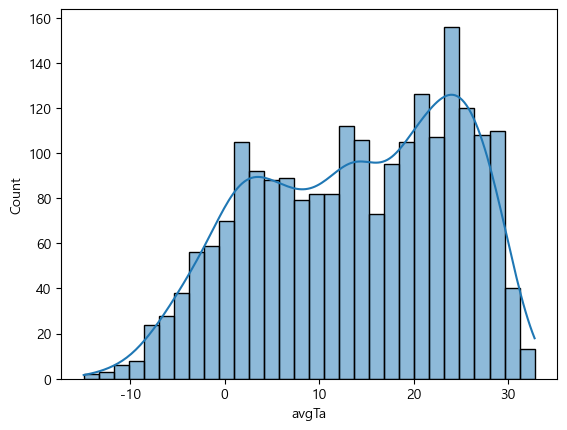

In [81]:
sns.histplot(data=df, x='avgTa', bins=30, kde=True)

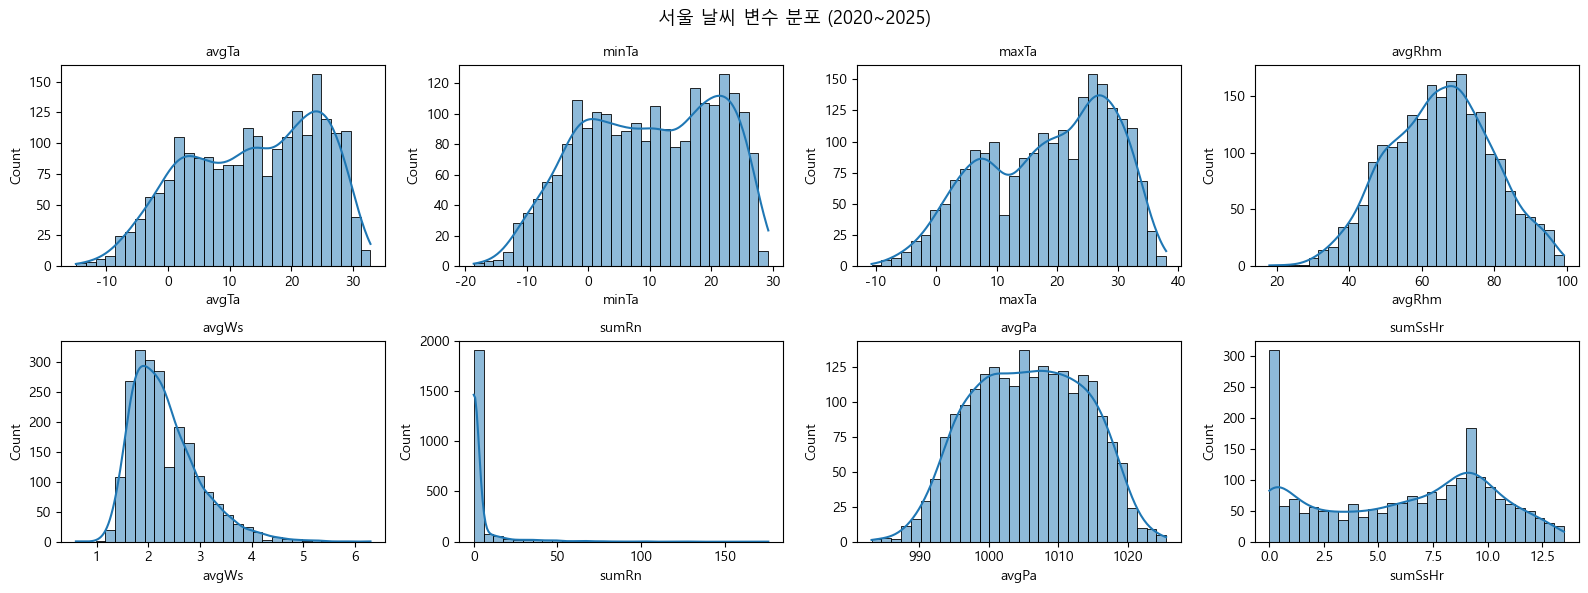

In [82]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()
cols =['avgTa', 'minTa', 'maxTa', 'avgRhm',
          'avgWs', 'sumRn', 'avgPa', 'sumSsHr']

for i, col in enumerate (cols):
    sns.histplot(data=df, x=col, bins=30, kde=True, ax=axes[i] )  
    axes[i].set_title(col, fontsize=10)
   
plt.suptitle('서울 날씨 변수 분포 (2020~2025)', fontsize=13)
plt.tight_layout()
plt.show()

In [83]:
df.columns

Index(['tm', 'avgTa', 'minTa', 'maxTa', 'avgRhm', 'avgWs', 'sumRn', 'avgPa',
       'sumSsHr', 'avgTca'],
      dtype='object')

In [84]:
df['tm']

0       2020-01-01
1       2020-01-02
2       2020-01-03
3       2020-01-04
4       2020-01-05
           ...    
2187    2025-12-27
2188    2025-12-28
2189    2025-12-29
2190    2025-12-30
2191    2025-12-31
Name: tm, Length: 2182, dtype: object

In [85]:
df['tm'] = pd.to_datetime(df['tm'])

In [86]:
df['month'] = df['tm'].dt.month

In [90]:
def find_season(month):
    if month in [3, 4, 5]:
        return 1  
    elif month in [6, 7, 8]:
        return 2  
    elif month in [9, 10, 11]:
        return 3  
    else:
        return 4  

In [91]:
df['season'] = df['month'].apply(find_season)

In [92]:
df['season'].value_counts()

season
2    551
1    549
3    543
4    539
Name: count, dtype: int64

## 머신러닝 분류

In [93]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [94]:
df.columns

Index(['tm', 'avgTa', 'minTa', 'maxTa', 'avgRhm', 'avgWs', 'sumRn', 'avgPa',
       'sumSsHr', 'avgTca', 'month', 'season'],
      dtype='object')

In [95]:
X= df[[ 'avgTa', 'minTa', 'maxTa', 'avgRhm', 'avgWs', 'sumRn', 'avgPa',
       'sumSsHr', 'avgTca']]
y= df['season']

In [96]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

In [97]:
rf = RandomForestClassifier(random_state=0)

In [98]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [99]:
y_pred = rf.predict(X_test)

In [100]:
acc= accuracy_score(y_test, y_pred)
precision= precision_score(y_test, y_pred, average='macro')
recall= recall_score(y_test, y_pred, average='macro')
f1= f1_score(y_test, y_pred, average='macro')
print(f'정확도 (Accuracy): {acc:.2f}')       
print(f'정밀도 (Precision): {precision:.2f}') 
print(f'재현율 (Recall): {recall:.2f}')      
print(f'f1-score: {f1:.2f}')   

정확도 (Accuracy): 0.81
정밀도 (Precision): 0.81
재현율 (Recall): 0.81
f1-score: 0.80


## 머신러닝 회귀

In [101]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [102]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [103]:
df.columns

Index(['tm', 'avgTa', 'minTa', 'maxTa', 'avgRhm', 'avgWs', 'sumRn', 'avgPa',
       'sumSsHr', 'avgTca', 'month', 'season'],
      dtype='object')

In [104]:
X= df[['avgTa', 'minTa', 'maxTa', 'avgWs', 'sumRn', 'avgPa', 'sumSsHr', 'avgTca']]

In [105]:
rf = RandomForestRegressor(random_state=0)

In [106]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [107]:
y_pred= rf.predict(X_test)

In [108]:
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'평균절대오차 (MAE): {mae:.2f}')
print(f'평균제곱근오차 (RMSE): {rmse:.2f}')
print(f'R2 Score: {r2:.2f}')

평균절대오차 (MAE): 0.41
평균제곱근오차 (RMSE): 0.70
R2 Score: 0.60


여러분 어느새 13주차 수업을 마쳤습니다    
오늘은 그동안 배운 머신러닝 분류와 회귀방법을        
공공데이터에 적용해 보았습니다        
기상 관련 전문 지식 없어도 분류와 회귀의 큰 흐름을 이해하면 쉽게 할 수 있었습니다  
이제 여러분들이 **기말 프로젝트를 위한 데이터를 찾아보고 기본적인 EDA 과정** 을 먼저 해볼 시간입니다   
그 후에 **머신러닝을 적용**해 볼 수 있는 데이터로 잘 찾아보시기 바랍니다  
물론 수업 시간에 한 내용에 한 두가지를 추가해서 해도 좋습니다    
아래 셀에 어떻게 공부하였는 지 여러분의 이야기를 저와 공유해주세요      

In [ ]:
오늘 실습을 통해 공공데이터에 머신러닝을 적용하는 전체적인 흐름을 확실히 익힐 수 있었습니다. 
배운 내용을 바탕으로 주말 동안 제가 관심 있는 분야의 공공데이터를 찾아보고, 기말 프로젝트를 준비해 보겠습니다